# Anomaly calculations

In [1]:
from earthkit import data as ekd
from earthkit import plots as ekp
from earthkit import transforms as ekt
from earthkit.transforms._tools import earthkit_remote_test_data_file

## Load some test data

In this example we will use hourly ERA5 2m temperature data on a 3˚ X 3˚ spatial grid for the years 2015 to 2017 as
our physical data.

All `earthkit-transforms` methods can be called with `earthkit-data` objects (Readers and Wrappers)
or with a pre-loaded `xarray`.
To reduce the number of conversions in the example, we will convert to xarray in the first cell
and use that data object for all subsequent steps. This also allows us to set some dataset specific options
in the conversion to xarray instead of relying on the default options.

In [2]:
# Get some demonstration ERA5 data, this could be any url or path to an ERA5 grib or netCDF file.
remote_era5_file = earthkit_remote_test_data_file("ERA5-Reading-2m-temperature-1940-2025.nc")
era5_data = ekd.from_source("url", remote_era5_file)
# convert to xarray to save repeated conversion in further steps.
# the .compute loads everything into memory which is safe for this example
era5_xr = era5_data.to_xarray().compute()
era5_xr

<xarray.Dataset> Size: 9MB
Dimensions:     (valid_time: 753888)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:...
    latitude    float64 8B 51.5
    longitude   float64 8B -1.0
Data variables:
    t2m         (valid_time) float32 3MB 270.2 270.4 269.6 ... 272.4 272.2 272.3
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## Calculate the daily climatology of the ERA5 data

In [3]:
climatology_mean = ekt.climatology.mean(era5_xr)
climatology_monthly_mean = ekt.climatology.monthly_mean(era5_xr)
climatology_mean

<xarray.Dataset> Size: 20B
Dimensions:    ()
Coordinates:
    latitude   float64 8B 51.5
    longitude  float64 8B -1.0
Data variables:
    t2m        float32 4B 283.2
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## Calculate the anomaly and relative anomaly

In [4]:
# The anomaly of the daily mean
anomaly_original_time_dim = ekt.climatology.anomaly(era5_xr, climatology_monthly_mean)
anomaly_original_time_dim

<xarray.Dataset> Size: 27MB
Dimensions:     (valid_time: 753888)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:...
    latitude    (valid_time) float64 6MB 51.5 51.5 51.5 51.5 ... 51.5 51.5 51.5
    longitude   (valid_time) float64 6MB -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0
    month       (valid_time) int64 6MB 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12
Data variables:
    t2m         (valid_time) float32 3MB -6.995 -6.768 -7.601 ... -5.929 -5.904
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [5]:
anomaly = ekt.climatology.anomaly(era5_xr, climatology_monthly_mean, frequency="month")
anomaly

<xarray.Dataset> Size: 12kB
Dimensions:     (valid_time: 1032)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-12-01
Data variables:
    t2m         (valid_time) float32 4kB -5.153 -0.5941 -0.4915 ... 1.752 2.078
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [6]:
relative_anomaly = ekt.climatology.relative_anomaly(era5_xr, climatology_monthly_mean, frequency="month")
relative_anomaly

<xarray.Dataset> Size: 12kB
Dimensions:     (valid_time: 1032)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-12-01
Data variables:
    t2m         (valid_time) float32 4kB -1.859 -0.2141 -0.176 ... 0.6254 0.7472
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## Plot the output for a random location

/opt/homebrew/Caskroom/miniforge/base/envs/rtd-dev-env/lib/python3.12/site-packages/earthkit/plots/metadata/labels.py:278: UserWarning: No key "latitude" found in layer metadata.
  warnings.warn(f'No key "{attr}" found in layer metadata.')
/opt/homebrew/Caskroom/miniforge/base/envs/rtd-dev-env/lib/python3.12/site-packages/earthkit/plots/metadata/labels.py:278: UserWarning: No key "longitude" found in layer metadata.
  warnings.warn(f'No key "{attr}" found in layer metadata.')


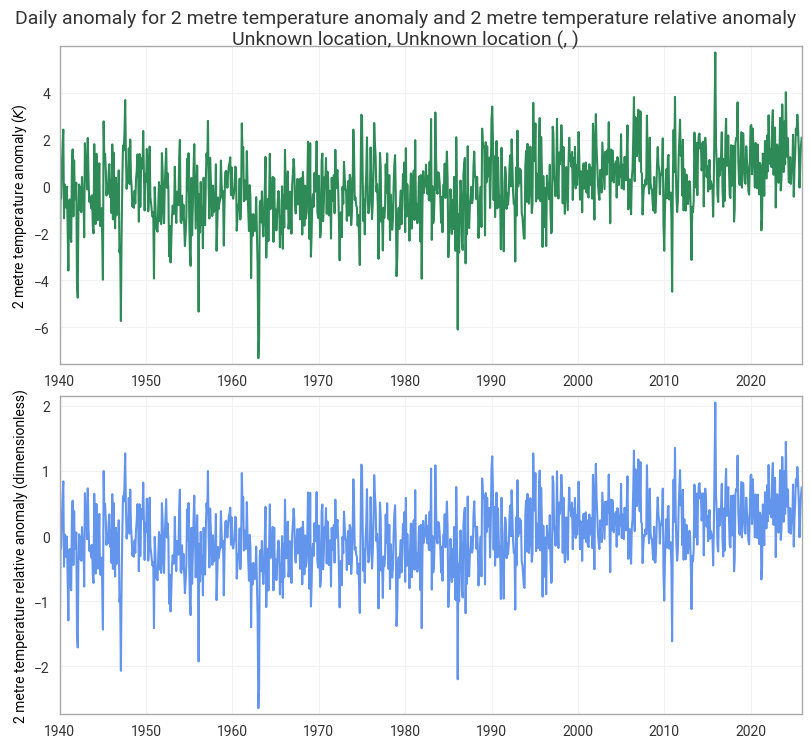

In [7]:
fig = ekp.Figure(rows=2, columns=1)

ts1 = fig.add_timeseries()
# Add the daily anomaly as a green solid line:
ts1.line(anomaly, label="Anomaly", color="seagreen")

ts2 = fig.add_timeseries()
# Add the relative anomaly as a blue dashed line:
ts2.line(relative_anomaly, units="percent", label="Relative anomaly", color="cornflowerblue")

fig.title("Daily anomaly for {variable_name}\n{location:%c}, {location:%C} ({latitude:%Lt}, {longitude:%Ln})")

ts1.ylabel()
ts2.ylabel()

fig.legend()

fig.show()